### 1. Что такое линейная регрессия?


**Линейная регрессия** — это самый простой и понятный способ в машинном обучении и статистике **предсказывать число** (не класс, а именно число: цену, температуру, зарплату, продажи и т.д.) на основе других чисел.

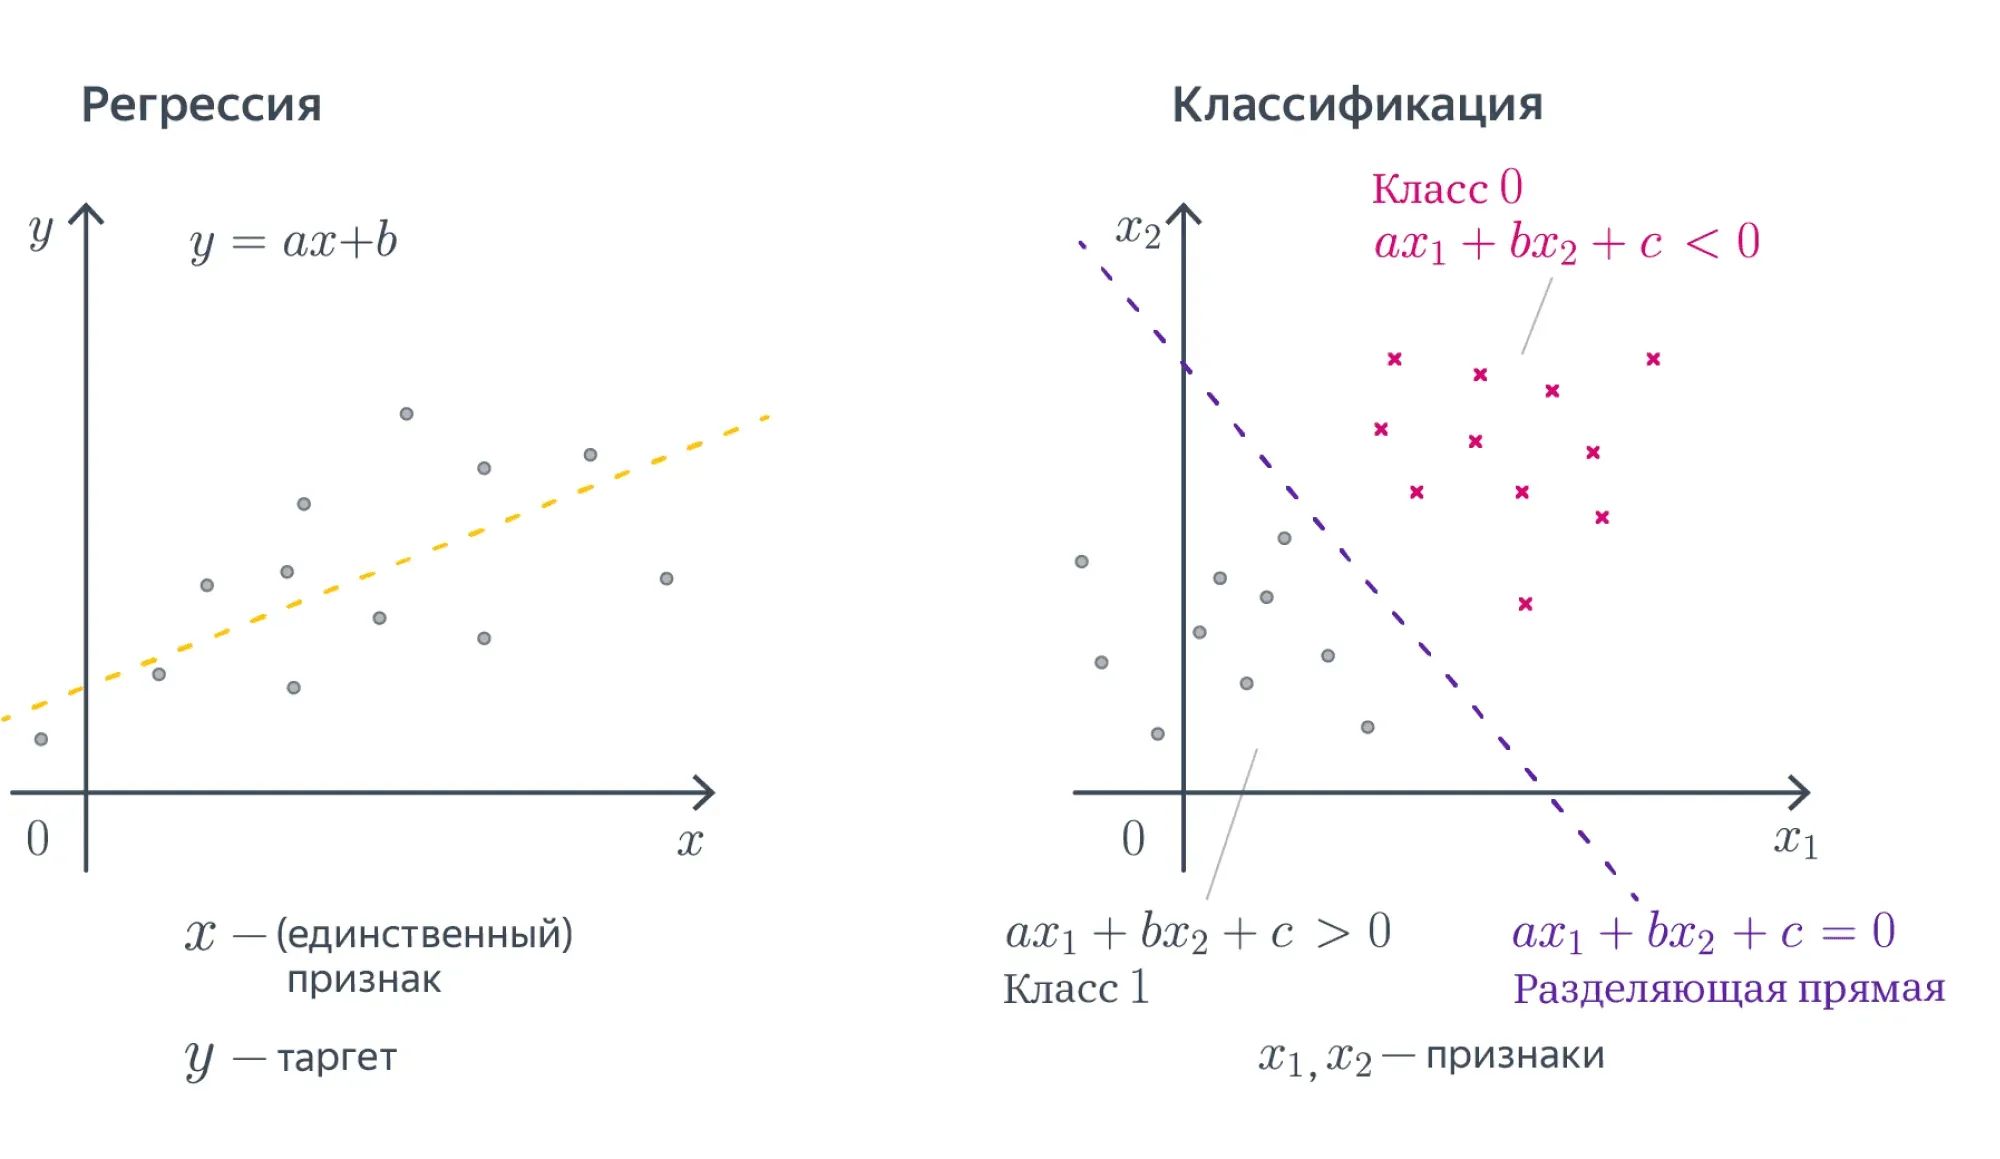

Представьте, что есть данные:

- площадь квартиры → цена  
- возраст человека → давление  
- количество часов учёбы → балл на экзамене  
- температура на улице → продажи мороженого  

Между этими величинами есть **примерно прямая зависимость** (чем больше площадь — тем дороже квартира, чем больше учился — тем выше балл и т.п.).

Линейная регрессия **находит лучшую прямую линию** (или плоскость в многомерном случае), которая описывает эту зависимость.

Математически это выглядит так:

$$
y = w_0 + w_1 x_1 + w_2 x_2 + \dots + w_m x_m + \varepsilon
$$

- $y$ — то, что мы хотим предсказать (зависимая переменная, target)  
- $x_1, x_2, \dots$ — признаки, по которым предсказываем (независимые переменные, features)  
- $w_0, w_1, \dots$ — коэффициенты (веса), которые модель подбирает  
- $\varepsilon$ — ошибка (шум), который мы не можем учесть

### Виды линейной регрессии

- **Простая** (Simple Linear Regression) — один признак  
  Пример: цена = w₀ + w₁ · площадь

- **Множественная** (Multiple Linear Regression) — много признаков  
  Пример: цена = w₀ + w₁ · площадь + w₂ · этаж + w₃ · расстояние_до_метро + ...

### Зачем нужна линейная регрессия?

1. **Прогнозирование** числовых значений  
2. **Анализ влияния** факторов (коэффициенты показывают, насколько сильно признак влияет на результат)  
3. **Понимание данных** — очень интерпретируемая модель  
4. **Базовый бенчмарк** — почти всегда начинают именно с неё  
5. **Основа** для более сложных моделей (регуляризованная регрессия, GLM и др.)

### Где применяется на практике?

- Недвижимость: предсказание цены квартиры  
- Маркетинг: прогнозирование продаж  
- Финансы: оценка риска, предсказание доходности  
- Медицина: зависимость давления от возраста/веса/курения  
- HR: предсказание зарплаты по опыту/образованию/навыкам  
- Производство: зависимость выхода продукции от температуры/давления/времени  
- Экономика: модели типа «ВВП от инвестиций и потребления»

### Плюсы линейной регрессии

- Очень **простая** и быстрая  
- **Легко интерпретировать** коэффициенты  
- Хорошо работает, когда зависимость действительно близка к линейной  
- Требует мало данных (иногда хватает 20–50 строк)  
- Есть строгие статистические тесты (p-value, R², доверительные интервалы)

### Минусы и ограничения

- Предполагает **линейную** зависимость (если кривая — модель будет плохой)  
- Чувствительна к **выбросам**  
- Плохо работает при **мультиколлинеарности** (сильная корреляция между признаками)  
- Предполагает независимость ошибок, гомоскедастичность, нормальность остатков (для корректных выводов)  
- Не может моделировать взаимодействия признаков без ручного добавления (x₁×x₂ и т.д.)

---
# Метод наименьших квадратов (МНК / Ordinary Least Squares)

---

### Что такое метод наименьших квадратов?

**Метод наименьших квадратов (МНК)** — это способ найти **лучшую прямую** (или гиперплоскость), которая проходит через облако точек данных так, чтобы сумма **квадратов расстояний** от каждой точки до этой прямой была **как можно меньше**.

Представьте, что вы рисуете линию через точки на графике «рост → вес».  
Каждая точка немного отклоняется от линии — это **остаток** (ошибка).  
МНК говорит: «Возьмём все остатки, возведём в квадрат (чтобы не компенсировали друг друга) и выберем такую линию, чтобы сумма этих квадратов была минимальной».

### Зачем он нужен?

- Самый популярный способ обучать **линейную регрессию**.
- Даёт **аналитическое** (точное) решение за одну операцию — не нужно итераций и градиентного спуска.
- Позволяет понять, как каждый признак влияет на результат (коэффициенты интерпретируемы).
- Лежит в основе почти всей классической статистики и эконометрики.

### Особенности метода

**Плюсы:**
- Простой и быстрый (для небольших данных).
- Имеет отличные статистические свойства (несмещённая оценка с минимальной дисперсией).
- Легко считать руками или в Excel.

**Минусы и особенности:**
- Очень чувствителен к **выбросам** (одна далёкая точка сильно «тянет» линию).
- Плохо работает при **мультиколлинеарности** (когда признаки сильно коррелируют друг с другом) — коэффициенты «взрываются».
- Требует выполнения условий Гаусса-Маркова (линейность, постоянная дисперсия ошибок, независимость ошибок).
- Если данных очень много (> 100 000), лучше использовать градиентный спуск.

**Главное отличие МНК** — он даёт **точный ответ** за один шаг, если матрица не вырожденная.

### Где применяется?

- Прогнозирование цены квартиры по площади и району
- Анализ, как зарплата зависит от опыта и образования
- Медицина: как давление зависит от возраста и веса
- Экономика, финансы, маркетинг — почти везде, где есть линейная зависимость



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Создаём простые данные
np.random.seed(42)
X = np.random.rand(15, 1) * 10                    # признак от 0 до 10
y = 2.5 * X.ravel() + 4 + np.random.randn(15) * 1.8   # настоящая зависимость + шум

# Обучаем МНК
model = LinearRegression()
model.fit(X, y)

# Рисуем
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', label='Данные')
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(X_line, model.predict(X_line), color='red', lw=3,
         label=f'МНК: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
plt.xlabel('Признак X')
plt.ylabel('Целевая переменная y')
plt.title('Метод наименьших квадратов — визуализация')
plt.legend()
plt.grid(True)
plt.show()

print(f'Уравнение прямой: y = {model.coef_[0]:.3f}·X + {model.intercept_:.3f}')


##2. Математика: формулы метода наименьших квадратов

Чтобы понять, как работает `LinearRegression` внутри, нам нужно перевести задачу на язык линейной алгебры.

### 1. Матричная запись модели
Вместо того чтобы писать длинное уравнение для каждого примера:
$$ y_i = w_0 + w_1 x_{i1} + w_2 x_{i2} + \dots + \epsilon_i $$

Мы записываем всё в компактном матричном виде:

$$ \vec{y} = X \vec{w} + \epsilon $$

**Где:**
*   $\vec{y}$ — вектор целевых значений (размер $n \times 1$).
*   $\vec{w}$ — вектор весов модели (размер $m \times 1$). Это то, что мы хотим найти.
*   $X$ — матрица признаков (размер $n \times m$).
    > **Важный трюк:** Чтобы учесть свободный член $w_0$ (сдвиг), к матрице $X$ слева добавляют столбец, состоящий из одних единиц. Тогда $w_0$ просто умножается на 1.
*   $\epsilon$ — вектор случайных ошибок (шум).

---

### 2. Функция потерь (Loss Function)
Мы хотим найти такие веса $\vec{w}$, чтобы наши предсказания $X\vec{w}$ были максимально близки к реальным $\vec{y}$.

В методе наименьших квадратов мы минимизируем **квадрат Евклидова расстояния** (L2-норму) между векторами:

$$ L(\vec{w}) = \sum_{i=1}^{n} (y_i - \vec{w}^T \vec{x}_i)^2 = ||\vec{y} - X\vec{w}||^2 \rightarrow \min $$

**Почему именно квадрат?**
1.  **Наказывает за большие ошибки:** Если ошибка выросла в 2 раза, штраф вырастет в 4 раза. Модель очень старается не допускать "выбросов".
2.  **Удобство:** Производная квадратичной функции — линейная. Это позволяет найти решение аналитически, без перебора.

---

### 3. Нормальное уравнение (Аналитическое решение)
Это "сердце" метода. Если взять производную от функции потерь по весам $\vec{w}$ и приравнять её к нулю ($\nabla_w L = 0$), мы получим формулу, которая сразу дает идеальные веса:

$$ \vec{w} = (X^T X)^{-1} X^T \vec{y} $$

**Разберем формулу по частям:**

1.  $X^T$ — **Транспонированная матрица**. Мы "кладем" матрицу признаков на бок.
2.  $X^T X$ — **Матрица Грама**. Квадратная матрица, которая показывает, как признаки коррелируют друг с другом.
3.  $(X^T X)^{-1}$ — **Обратная матрица**. Самая сложная операция. Если признаки сильно зависимы (мультиколлинеарность), определитель этой матрицы близок к нулю, и найти обратную матрицу становится невозможно или решение становится неустойчивым.
4.  $X^T \vec{y}$ — Вектор, показывающий корреляцию признаков с целевой переменной.

---

### 4. Вероятностный смысл (Связь с теорией вероятностей)
Почему мы минимизируем именно квадрат ошибки, а не модуль?

Если предположить, что шум в данных ($\epsilon$) распределен **нормально** (по Гауссу) с нулевым средним:
$$ \epsilon \sim \mathcal{N}(0, \sigma^2) $$

То **Метод Максимального Правдоподобия** (Maximum Likelihood Estimation) приводит нас ровно к той же формуле, что и МНК.
То есть, минимизируя квадраты ошибок, мы неявно предполагаем, что шум в данных — нормальный.

In [ ]:
import numpy as np

# Простые данные: 5 точек
X = np.array([[1, 1],    # колонка единиц + признак
              [1, 2],
              [1, 3],
              [1, 4],
              [1, 5]])
y = np.array([2.1, 3.9, 5.2, 4.8, 6.1])

# МНК вручную
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
Xty = X.T @ y
w_manual = XtX_inv @ Xty

print(f'МНК вручную: w0 = {w_manual[0]:.3f}, w1 = {w_manual[1]:.3f}')

# Проверка через sklearn
from sklearn.linear_model import LinearRegression
model = LinearRegression(fit_intercept=False)  # уже есть колонка единиц
model.fit(X, y)
print(f'sklearn:       w0 = {model.coef_[0]:.3f}, w1 = {model.coef_[1]:.3f}')

##2. Математика на примере дата сета с двумя признаками

Если мы возьмем квадратичную ошибку
и минимизирую её, решив новую СЛАУ из производных по всем $k$ и $C$,
то это и будет применение метода наименьших квадратов (OLS).

Рассмотрим пример с двумя признаками и свободным коэффициентом $C$:

$$
\sum_{i=1}^{n}
\left(
y_i - k_1 x_{1i} - k_2 x_{2i} - C
\right)^2
\;\rightarrow\; \min
$$

Здесь:

- $x_{1i}, x_{2i}$ — известные признаки (из исходных данных),
- $y_i$ — целевая переменная,
- $k_1, k_2, C$ — неизвестные параметры модели.

Будем дифференцировать по $k_1$, $k_2$ и $C$.
Признаки $X$ при этом рассматриваются как фиксированные числа.


Поскольку мы ищем экстремум, в искомой точке производная по параметрам равна нулю:

$$
\frac{\partial OLS}{\partial C} = 0,
\qquad
\frac{\partial OLS}{\partial k_1} = 0,
\qquad
\frac{\partial OLS}{\partial k_2} = 0.
$$

Получается, есть 3 выражения с тремя неизвестными, приравненные к нулю.  
Это искомая СЛАУ.

Именно СЛАУ, так как $x_i$ — это просто числа (в любой степени).


В итоге получаем:

$$
\sum_{i=1}^{n} x_{1i} y_i
=
C \sum_{i=1}^{n} x_{1i}
-
k_1 \sum_{i=1}^{n} x_{1i}^2
-
k_2 \sum_{i=1}^{n} x_{1i} x_{2i}.
$$

$$
\frac{\partial OLS}{\partial C}
=
-2 \sum_{i=1}^{n}
\left( y_i - C - k_1 x_{1i} - k_2 x_{2i} \right)
$$

$$
\frac{\partial OLS}{\partial k_1}
=
-2 \sum_{i=1}^{n}
x_{1i}
\left( y_i - C - k_1 x_{1i} - k_2 x_{2i} \right)
$$

$$
\frac{\partial OLS}{\partial k_2}
=
-2 \sum_{i=1}^{n}
x_{2i}
\left( y_i - C - k_1 x_{1i} - k_2 x_{2i} \right)
$$

В новой СЛАУ всё — числа, кроме коэффициентов.
Параметры $C, k_1, k_2$ — неизвестные.

Исходные данные:

| $x_1$ | $x_2$ | $y$ |
|------|------|------|
| 1 | 2 | 1.5 |
| 2 | 3 | 1.8 |
| 3 | 1 | 3.2 |
| 4 | 5 | 3.6 |
| 5 | 4 | 5.1 |

После подстановки получаем систему:

$$
15.2 = 5C + 15k_1 + 15k_2
$$

$$
54.6 = 15C + 55k_1 + 51k_2
$$

$$
50.0 = 15C + 51k_1 + 55k_2
$$

После решения системы находятся коэффициенты $C, k_1, k_2$.


##Минимизация функции потерь:
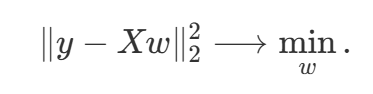

 Метод наименьших квадратов (МНК) минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью:


$\large \begin{array}{rcl}\mathcal{L}\left(X, \vec{y}, \vec{w} \right) &=& \frac{1}{2n} \sum_{i=1}^n \left(y_i - \vec{w}^T \vec{x}_i\right)^2 \\ &=& \frac{1}{2n} \left\| \vec{y} - X \vec{w} \right\|_2^2 \\ &=& \frac{1}{2n} \left(\vec{y} - X \vec{w}\right)^T \left(\vec{y} - X \vec{w}\right) \end{array}$


Для решения данной оптимизационной задачи необходимо вычислить производные по параметрам модели, приравнять их к нулю и решить полученные уравнения относительно $\vec w$:


$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} &=& \frac{\partial}{\partial \vec{w}} \frac{1}{2n} \left( \vec{y}^T \vec{y} -2\vec{y}^T X \vec{w} + \vec{w}^T X^T X \vec{w}\right) \\ &=& \frac{1}{2n} \left(-2 X^T \vec{y} + 2X^T X \vec{w}\right) \end{array}$


$\large \begin{array}{rcl} \frac{\partial \mathcal{L}}{\partial \vec{w}} = 0 &\Leftrightarrow& \frac{1}{2n} \left(-2 X^T \vec{y} + 2X^T X \vec{w}\right) = 0 \\ &\Leftrightarrow& -X^T \vec{y} + X^T X \vec{w} = 0 \\ &\Leftrightarrow& X^T X \vec{w} = X^T \vec{y} \\ &\Leftrightarrow& \vec{w} = \left(X^T X\right)^{-1} X^T \vec{y} \end{array}$



Подставляем веса обратно в функцию ошибок

## 3. Геометрический смысл: Что такое остатки?

МНК расшифровывается как **Метод наименьших квадратов**. Каких именно квадратов?

Посмотрите на график ниже:
*   **Черные пунктирные линии** — это ошибки, то есть остатки. Расстояние от точки до прямой.
*   Метод ищет такую красную линию, чтобы **сумма квадратов длин этих пунктиров** была минимальной.

Если мы сдвинем линию хоть на миллиметр, сумма квадратов ошибок вырастет.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
X = np.random.rand(20, 1) * 10
y = 3 * X.ravel() + 5 + np.random.randn(20) * 2

model = LinearRegression().fit(X, y)
a = model.coef_[0]
b = model.intercept_

fig, ax = plt.subplots(figsize=(12, 6))

# Точки
ax.scatter(X, y, color='blue', label='Данные', zorder=3)

# Прямая (в пределах 0..10 как на твоём примере)
x_line = np.linspace(0, 10, 200)
ax.plot(x_line, a * x_line + b, color='red', lw=3,
        label=f'МНК: y = {a:.2f}x + {b:.2f}', zorder=2)

# Масштаб/лимиты как обычно (без equal)
ax.set_xlim(0, 10.5)
y_min = min(y.min(), (a * x_line + b).min())
y_max = max(y.max(), (a * x_line + b).max())
ax.set_ylim(y_min - 2, y_max + 2)

# Нужно, чтобы трансформации осей были готовы
fig.canvas.draw()

# Линия в экранных координатах (для визуально перпендикулярных отрезков)
p1 = np.array([0.0, b])
p2 = np.array([1.0, a + b])
P1 = ax.transData.transform(p1)
P2 = ax.transData.transform(p2)

v = P2 - P1
v = v / np.linalg.norm(v)

# Пунктирные перпендикуляры от точек к прямой (проекция на прямую в экранных координатах)
for x0, y0 in zip(X.ravel(), y):
    P = ax.transData.transform([x0, y0])

    t = np.dot(P - P1, v)
    P_proj = P1 + t * v

    x_proj, y_proj = ax.transData.inverted().transform(P_proj)
    ax.plot([x0, x_proj], [y0, y_proj], 'k--', lw=1.2, alpha=0.8, zorder=1)

ax.set_title('Метод наименьших квадратов — визуализация')
ax.set_xlabel('Признак X')
ax.set_ylabel('Целевая переменная y')
ax.grid(True)
ax.legend(loc='upper left')

# (опционально) подпись уравнения внизу слева, как на скрине
fig.text(0.02, 0.02, f'Уравнение прямой:  y = {a:.3f}·x + {b:.3f}', fontsize=10)

plt.show()

## 4. Множественная регрессия

В реальности на цену влияют разные факторы. Например, цена квартиры зависит от:
1.  **Площади** (сильно).
2.  **Количества комнат** (сильно).

Мы генерируем данные, где цена складывается из этих факторов + шум.
**Высокий R²** (около 0.9) — это значит, что модель отлично уловила зависимость.

In [ ]:
# Множественная линейная регрессия
import numpy as np
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 50

# Генерируем данные
area = np.random.uniform(30, 120, n)  # Площадь от 30 до 120 м2
rooms = np.random.randint(1, 5, n)    # Комнаты от 1 до 4

# Формула цены (в тысячах рублей):
# 100 тыс. за кв.м + 500 тыс. за комнату + шум
price = 100 * area + 500 * rooms + np.random.normal(0, 500, n)

X = np.column_stack((area, rooms))
y = price

model = LinearRegression()
model.fit(X, y)

print(f'Уравнение: цена = {model.intercept_:.2f} + '
      f'{model.coef_[0]:.2f}·площадь + '
      f'{model.coef_[1]:.2f}·комнаты (тыс.руб.)')

print(f'R² = {model.score(X, y):.3f}')
# R² должен получиться высоким (около 0.9), так как мы уменьшили шум

## 5. Ridge-регрессия и важность масштабирования

Здесь мы используем **Ridge** (регрессию с регуляризацией), которая штрафует модель за слишком большие веса.

**Проблема:**
*   Площадь — это числа порядка 100.
*   Комнаты — это числа порядка 1.

Если не привести их к одному масштабу, Ridge подумает, что "комнаты" — неважный признак (ведь число маленькое), или наоборот, будет несправедливо штрафовать его большой вес.

**Решение:**
Мы используем `StandardScaler` внутри `Pipeline`.
Посмотрите на таблицу в конце:
*   **Без скалирования:** вес при комнатах занижен (ошибка!).
*   **С Pipeline:** модель нашла верные веса.

In [ ]:
# ПРИМЕР RIDGE-РЕГРЕССИИ (С МАСШТАБИРОВАНИЕМ)
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

np.random.seed(42)
n = 50

# 1. Генерируем данные с РАЗНЫМ масштабом
# Площадь: большие числа (30 - 120 кв.м)
area = np.random.uniform(30, 120, n)
# Комнаты: маленькие числа (1 - 5 комнат)
rooms = np.random.randint(1, 5, n)

#формула: Цена = 50 * площадь + 500 * комнаты + шум
price = 50 * area + 500 * rooms + np.random.normal(0, 100, n)

X = np.column_stack((area, rooms))
y = price

# 2. Обучение без масштабирования (плохо для Ridge)
# Ridge увидит, что вес при "rooms" должен быть огромным (500),и начнет его сильно штрафовать, считая это "переобучением".
ridge_wrong = Ridge(alpha=10.0)
ridge_wrong.fit(X, y)

# 3. Обучение с масштабированием (Правильно)
# StandardScaler переводит все признаки в диапазон, где среднее=0, а разброс=1.
# Теперь Ridge видит реальную важность признаков.
# Используем Pipeline — это профессиональный стандарт в sklearn.
model_pipeline = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
model_pipeline.fit(X, y)

# Достаем коэффициенты из Pipeline (шаг 'ridge')
coef_scaled = model_pipeline.named_steps['ridge'].coef_

# 4. Сравнение результатов
print("Сравнение весов моделей:")
results = pd.DataFrame({
    'Признак': ['Площадь (Area)', 'Комнаты (Rooms)'],
    'Истинный коэффициент': [50.0, 500.0],
    'Ridge (Без скалирования)': ridge_wrong.coef_,
    'Ridge (С правильным скалированием*)': coef_scaled
})

print(results.round(2))
print("\n*Примечание: Коэффициенты масштабированной модели нельзя сравнивать напрямую с рублевыми ценами,")
print("но они показывают реальную силу влияния признака внутри модели.")
print("-" * 60)

# Демонстрация предсказания
test_flat = np.array([[50, 2]])
pred_wrong = ridge_wrong.predict(test_flat)[0]
pred_right = model_pipeline.predict(test_flat)[0]

print(f"Предсказание цены для квартиры 50м², 2 комн:")
print(f"Без скалирования: {pred_wrong:.2f} (Ошибка из-за штрафа важного признака)")
print(f"С Pipeline:       {pred_right:.2f} (Ближе к истине)")

## 6. Диагностика модели

Как понять, можно ли верить модели? Нужно посмотреть на её ошибки - остатки.

1.  **Распределение остатков:** Должен быть "колокол". Если он кривой — модель смещена.
2.  **Q-Q plot:** Точки должны лежать на красной линии. Это тест на нормальность.
3.  **Остатки vs Предсказания:** Точки должны быть разбросаны хаотично. Если видите узор — значит, данные нелинейные, и прямая линия тут не подходит.

In [ ]:
### Диагностика модели (проверка остатков)

import seaborn as sns
import scipy.stats as stats

# Предсказания и остатки
y_pred = model.predict(X)
residuals = y - y_pred

plt.figure(figsize=(14, 5))

# 1. Распределение остатков
plt.subplot(1, 3, 1)
sns.histplot(residuals, kde=True)
plt.title('Распределение остатков')

# 2. Q-Q plot (проверка нормальности)
plt.subplot(1, 3, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot остатков')

# 3. Остатки vs предсказанные значения
plt.subplot(1, 3, 3)
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки vs Предсказания')
plt.tight_layout()
plt.show()

**Теоретические вопросы**

В чем фундаментальное отличие задачи, которую решает линейная регрессия, от задачи классификации?

Ответ: линейная регрессия решает задачу предсказания числового значения: цены, зарплаты, температуры, продаж и т.д. Классификация же предсказывает категорию или класс, например «да/нет», «купит/не купит», «класс 0/1». Поэтому в регрессии результат лежит на числовой шкале, а в классификации результат относится к дискретным группам.

МНК расшифровывается как «Метод наименьших квадратов». Что конкретно мы возводим в квадрат?

Ответ: мы возводим в квадрат остатки, то есть ошибки между настоящими значениями и предсказаниями модели: \(y_i - \hat{y}_i\). МНК подбирает такую прямую или гиперплоскость, чтобы сумма этих квадратов была минимальной.

Большинство современных алгоритмов (например, нейросети) учатся постепенно, шагами подбирая правильный ответ. МНК же находит идеальные веса модели мгновенно. За счет какого математического свойства это возможно?

Ответ: функция потерь МНК является квадратичной по весам, поэтому её производные дают систему линейных уравнений. При выполнении условий обратимости матрицы \(X^T X\) веса можно найти аналитически через нормальное уравнение: \(w = (X^T X)^{-1}X^Ty\).

Если мы посмотрим на график с точками данных и проведенной линией регрессии, что именно представляет собой остаток - ошибка?

Ответ: остаток — это разница между фактическим значением точки и значением, которое предсказала линия регрессии. На графике это расстояние от наблюдения до линии по вертикали: \(e_i = y_i - \hat{y}_i\). Именно квадраты этих расстояний минимизирует МНК.
